#  Aioli Menu Analysis

## Project Goal
The goal of this project is to analyze menu items from Aioli restaurants in Poland by enriching them with nutritional information such as:
- Macro (protein, fats, carbs)
- Caloric values
- Nutri-Score 


Based on this data, the project aims to explore relationships between:
- Food healthiness and price
- Differences in menu composition across cities in Poland
- Overall nutritional quality of the restaurant's offerings

Menu data is collected by scraping the official Aioli restaurant websites using `requests` and `BeautifulSoup`.

The dataset includes multiple locations in Poland:
- Warszawa (Świętokrzyska, Chmielna)
- Gdańsk
- Katowice

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import json
import os
import time
from openai import OpenAI
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
all_locations = {
    "Warszawa_Świętokrzyska": "https://aioli.com.pl/menu-warszawa-swietokrzyska/",
    "Warszawa_Chmielna": "https://aioli.com.pl/menu-warszawa-chmielna/",
    "Gdańsk": "https://aioli.com.pl/menu-gdansk/",
    "Katowice": "https://aioli.com.pl/menu-katowice/"}

### Data Extraction Logic
A custom function is used to iterate through HTML elements and extract specific menu sections from each location webpage.

The analysis is limited to main dishes and breakfast items, as other sections contain either irrelevant information or inconsistent formats that would reduce data quality.

Each extracted dish is stored as a dictionary containing:
- Category
- Dish name
- Portion size
- Ingredients
- Price
- Location


The results are aggregated into a single dataset

In [47]:
def extract_section(section_name, location, url):

    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    soup = BeautifulSoup(response.text, "html.parser")
    data = []

    for h2 in soup.find_all("h2"):
        if section_name in h2.get_text():
            section = h2.find_parent("div", class_="container")
            items = section.find_all("div", class_="py-20")

            for item in items:
                try:
                    h4 = item.find("h4")
                    if not h4:
                        continue

                    spans = h4.find_all("span")
                    dish_name = spans[0].get_text(strip=True) if len(spans) > 0 else None
                    dish_size = spans[1].get_text(strip=True) if len(spans) > 1 else None

                    p_tag = item.find("p")
                    ingredients = p_tag.get_text(strip=True) if p_tag else None

                    price_tag = item.find("span", class_="block")
                    price = price_tag.get_text(strip=True) if price_tag else None

                    data.append({
                        "category": section_name,
                        "dish_name": dish_name,
                        "dish_size": dish_size,
                        "ingredients": ingredients,
                        "price": price,
                        "location": location
                    })
                except Exception as e:
                    print(f"Error for {location}: {e}")
                    continue
                
    return data 

In [48]:
all_data = []

for location, url in all_locations.items():
    try:
        all_data += extract_section("Menu główne", location, url)
        all_data += extract_section("Śniadania", location, url)
        print(f"Scraping complete for {location}")
    except:
        print(f"Download failed for {location}")

Scraping complete for Warszawa_Świętokrzyska
Scraping complete for Warszawa_Chmielna
Scraping complete for Gdańsk
Scraping complete for Katowice


In [49]:
initial_df = pd.DataFrame(all_data)
initial_df.head()

,category,dish_name,dish_size,ingredients,price,location
0,Menu główne,AïOLI BEEF TATAR 2.0,350,"rostbef, owoc kaparowca, cebula, ogórek kiszon...","45,99",Warszawa_Świętokrzyska
1,Menu główne,AïOLI VEGE TATAR,330 g,"pomidor, cebula, ogórek kiszony, kiełki groszk...","37,99",Warszawa_Świętokrzyska
2,Menu główne,SWEET POTATO CHIPS,125 g,"chipsy z batata, parmezan, sos AïOLI","29,99",Warszawa_Świętokrzyska
3,Menu główne,ROASTED CABBAGE,300 g,"grillowana kapusta, sambal, kremowy serek, oli...","32,99",Warszawa_Świętokrzyska
4,Menu główne,TEMPURA CRISPY WINGS,450 g,"skrzydełka z kurczaka w pikantnej tempurze, so...","39,99",Warszawa_Świętokrzyska


In [50]:
print(f'There are {initial_df.shape[0]} rows and {initial_df.shape[1]} columns in the dataset.')

There are 208 rows and 6 columns in the dataset.


In [51]:
print(f'There are {initial_df['dish_name'].nunique()} unique dishes on the menu')

There are 53 unique dishes on the menu


In [52]:
initial_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   category     208 non-null    str  
 1   dish_name    208 non-null    str  
 2   dish_size    208 non-null    str  
 3   ingredients  208 non-null    str  
 4   price        204 non-null    str  
 5   location     208 non-null    str  
dtypes: str(6)
memory usage: 9.9 KB


In [53]:
initial_df[initial_df['price'].isnull()]

,category,dish_name,dish_size,ingredients,price,location
28,Menu główne,DODATKI,,extra frytki 110g 9.99 PLN\nextra wołowina 180...,NaN,Warszawa_Świętokrzyska
81,Menu główne,DODATKI,,extra frytki 110g 9.99 PLN\nextra wołowina 180...,NaN,Warszawa_Chmielna
133,Menu główne,DODATKI,,extra frytki 110g 9.99 PLN\nextra wołowina 180...,NaN,Gdańsk
184,Menu główne,DODATKI,,extra frytki 110g 9.99 PLN\nextra wołowina 180...,NaN,Katowice


In [54]:
initial_df.dropna(subset=['price'], inplace=True)

In [55]:
initial_df.info()

<class 'pandas.DataFrame'>
Index: 204 entries, 0 to 207
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   category     204 non-null    str  
 1   dish_name    204 non-null    str  
 2   dish_size    204 non-null    str  
 3   ingredients  204 non-null    str  
 4   price        204 non-null    str  
 5   location     204 non-null    str  
dtypes: str(6)
memory usage: 11.2 KB


Cleaning the price column to convert it into float:

In [56]:
initial_df["price"] = (initial_df["price"].str.replace(",", ".", regex=False).astype(float))
initial_df.head(5)

,category,dish_name,dish_size,ingredients,price,location
0,Menu główne,AïOLI BEEF TATAR 2.0,350,"rostbef, owoc kaparowca, cebula, ogórek kiszon...",45.99,Warszawa_Świętokrzyska
1,Menu główne,AïOLI VEGE TATAR,330 g,"pomidor, cebula, ogórek kiszony, kiełki groszk...",37.99,Warszawa_Świętokrzyska
2,Menu główne,SWEET POTATO CHIPS,125 g,"chipsy z batata, parmezan, sos AïOLI",29.99,Warszawa_Świętokrzyska
3,Menu główne,ROASTED CABBAGE,300 g,"grillowana kapusta, sambal, kremowy serek, oli...",32.99,Warszawa_Świętokrzyska
4,Menu główne,TEMPURA CRISPY WINGS,450 g,"skrzydełka z kurczaka w pikantnej tempurze, so...",39.99,Warszawa_Świętokrzyska


In [57]:
initial_df['price'].describe()

count    204.000000
mean      49.999804
std       22.918573
min       22.990000
25%       34.990000
50%       45.990000
75%       52.990000
max      145.990000
Name: price, dtype: float64

In [58]:
print('Most expensive unique dishes on the menu:')
initial_df.groupby('dish_name')['price'].max().nlargest(5).reset_index()

Most expensive unique dishes on the menu:


,dish_name,price
0,AïOLI SEASONAL STEAK,145.99
1,AïOLI SHARING SEAFOOD,129.99
2,SURF & TURF 2.0,97.99
3,GREEN PEPPER STEAK,89.99
4,CLASSIC NY STEAK,85.99


In [59]:
print('Cheapest dishes on the menu:')
initial_df.groupby('dish_name')['price'].max().nsmallest(5).reset_index()

Cheapest dishes on the menu:


,dish_name,price
0,CREMA DI POMODORO,22.99
1,ZUPA DNIA,22.99
2,AïOLI BREAKKIE PIZZA VEGE,28.99
3,SWEET POTATO CHIPS,29.99
4,TRUFFLE SCRAMBLE TOAST,29.99


In [60]:
initial_df[initial_df['dish_name']=='ZUPA DNIA']

,category,dish_name,dish_size,ingredients,price,location
13,Menu główne,ZUPA DNIA,450 ml,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",22.99,Warszawa_Świętokrzyska
66,Menu główne,ZUPA DNIA,450 ml,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",22.99,Warszawa_Chmielna
118,Menu główne,ZUPA DNIA,450 ml,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",22.99,Gdańsk
169,Menu główne,ZUPA DNIA,450 ml,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",22.99,Katowice


In [61]:
initial_df = initial_df[initial_df['dish_name'] != 'ZUPA DNIA']

### Checking whether weights make sense:

In [62]:
print(f'Weights of dishes on the menu: {initial_df['dish_size'].unique()}')
print(f'Minumum weight of a dish on the menu: {initial_df['dish_size'].unique().min()}')
print(f'Maximum weight of a dish on the menu: {initial_df['dish_size'].unique().max()}')

Weights of dishes on the menu: <StringArray>
[  '350', '330 g', '125 g', '300 g', '450 g', '225 g', '220 g', '230 g',
 '600 g', '540 g', '570 g', '520 g', '310 g', '550 g', '38 cm', '420 g',
 '525 g', '500 g', '190 g', '390 g', '380 g', '364 g', '620 G', '360 g',
 '370 g',  '28cm', '340 g', '400 g', '430 g', '315 g', '385 g']
Length: 31, dtype: str
Minumum weight of a dish on the menu: 125 g
Maximum weight of a dish on the menu: 620 G


In [63]:
pizzas_no = len(initial_df['dish_size'].where((initial_df['dish_size'] == '38 cm')|(initial_df['dish_size'] == '28 cm')).dropna())

In [64]:
print(f'Pizza has size and not weight on the menu and there are {pizzas_no} such positions on the menu. We will handle this in the Chat GPT prompt.')

Pizza has size and not weight on the menu and there are 36 such positions on the menu. We will handle this in the Chat GPT prompt.


In [65]:
initial_df[["dish_size", "unit"]] = initial_df["dish_size"].str.extract(r"(\d+\.?\d*)\s*([a-zA-Z]+)?")
initial_df["dish_size"] = pd.to_numeric(initial_df["dish_size"])

In [66]:
initial_df.info()

<class 'pandas.DataFrame'>
Index: 200 entries, 0 to 207
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     200 non-null    str    
 1   dish_name    200 non-null    str    
 2   dish_size    200 non-null    int64  
 3   ingredients  200 non-null    str    
 4   price        200 non-null    float64
 5   location     200 non-null    str    
 6   unit         196 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 12.5 KB


In [67]:
for col in initial_df.columns:
    print(col)
    print(initial_df[col].unique())
    print()

category
<StringArray>
['Menu główne', 'Śniadania']
Length: 2, dtype: str

dish_name
<StringArray>
[           'AïOLI BEEF TATAR 2.0',                'AïOLI VEGE TATAR',
              'SWEET POTATO CHIPS',                 'ROASTED CABBAGE',
            'TEMPURA CRISPY WINGS',       'LOADED FRIES & BEEF BITES',
            'BLACK GARLIC SHRIMPS',             'BUTTER WINE SHRIMPS',
                 'KATAIFI SHRIMPS',              'AïOLI SHARING MEAT',
              'AïOLI SHARING VEGE',           'AïOLI SHARING SEAFOOD',
               'CREMA DI POMODORO',                    'AïOLI BURGER',
                    'SMASH BURGER',       'PHILLY CHEESESTEAK BURGER',
                 'REUBEN SANDWICH',     'KOREAN FRIED CHICKEN BURGER',
                      'MARGHERITA',    'TARTUFO & SWEET POTATO CHIPS',
                 'BURRATA & COTTO',       'NDUJA & CARAMELIZED ONION',
          'TARTUFO & COTTO BIANCA',           'SALAMI & CHILLI HONEY',
                    'KIMCHI PIZZA',              

In [68]:
initial_df.describe(include='all')

,category,dish_name,dish_size,ingredients,price,location,unit
count,200,200,200.000000,200,200.000000,200,196
unique,2,51,NaN,52,NaN,4,3
top,Menu główne,AïOLI BEEF TATAR 2.0,NaN,"rostbef, owoc kaparowca, cebula, ogórek kiszon...",NaN,Warszawa_Świętokrzyska,g
freq,156,4,NaN,4,NaN,51,148
mean,NaN,NaN,316.040000,NaN,50.540000,NaN,NaN
std,NaN,NaN,185.050362,NaN,22.822397,NaN,NaN
min,NaN,NaN,28.000000,NaN,22.990000,NaN,NaN
25%,NaN,NaN,190.000000,NaN,35.990000,NaN,NaN
50%,NaN,NaN,335.000000,NaN,45.990000,NaN,NaN
75%,NaN,NaN,450.000000,NaN,52.990000,NaN,NaN


### Dataset Overview

The dataset consists of **191 menu items** across 4 restaurant locations, with no missing values.

### Key characteristics:
- 2 categories: main dishes and breakfast items
- 48 unique dishes with some repetition across locations
- Price ranges from **22.99 PLN to 145.99 PLN**, with an average of ~50 PLN

The data is well-structured and ready for further enrichment and exploratory analysis.

### Creating a unique identifier for dishes:

In [69]:
initial_df.insert(0, "dish_id", [i for i in range(1, len(initial_df) + 1)])

Check whether each menu item has the same number of items:

In [70]:
initial_df['location'].value_counts()

location
Warszawa_Świętokrzyska    51
Warszawa_Chmielna         50
Katowice                  50
Gdańsk                    49
Name: count, dtype: int64

In [71]:
dishes = initial_df[['dish_id', 'dish_name', 'dish_size', 'unit', 'price','category', 'location']]
dishes.head()

,dish_id,dish_name,dish_size,unit,price,category,location
0,1,AïOLI BEEF TATAR 2.0,350,NaN,45.99,Menu główne,Warszawa_Świętokrzyska
1,2,AïOLI VEGE TATAR,330,g,37.99,Menu główne,Warszawa_Świętokrzyska
2,3,SWEET POTATO CHIPS,125,g,29.99,Menu główne,Warszawa_Świętokrzyska
3,4,ROASTED CABBAGE,300,g,32.99,Menu główne,Warszawa_Świętokrzyska
4,5,TEMPURA CRISPY WINGS,450,g,39.99,Menu główne,Warszawa_Świętokrzyska


In [72]:
dishes.info()

<class 'pandas.DataFrame'>
Index: 200 entries, 0 to 207
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   dish_id    200 non-null    int64  
 1   dish_name  200 non-null    str    
 2   dish_size  200 non-null    int64  
 3   unit       196 non-null    str    
 4   price      200 non-null    float64
 5   category   200 non-null    str    
 6   location   200 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.5 KB


Save data to csv for manual review

In [73]:
dishes.to_csv('data/dishes.csv')

In [74]:
client = OpenAI(api_key=os.getenv("API_KEY"))

def get_batch_recipes(df):

    data = df[["dish_id", "ingredients", "dish_size"]].to_dict(orient="records")

    prompt = f"""Jesteś ścisłym generatorem JSON.

    Zwróć TYLKO prawidłowy JSON.
    Brak przeceny.
    Żadnych wyjaśnień.
    Brak tekstu przed i po formacie JSON.

    Każde danie musi zawierać szacunkową masę składników. Rozwiń listę składników, aby była bardziej szczegółowa, 
    tj. nie „skrzydełka z kurczaka w pikantnej panierce” tylko skrzydełko z kurczaka, bułka tarta, mąka, olej.
    Jeśli danie to pizza to oszacuj gramaturę na podstawie jej średnicy. Dla każdej pizzy o tej samej średnicy podaj taką samą gramaturę ciasta!
    
    Najmniejsza możliwa gramatura składnika to 0.5g, a największa nie może przekraczać wagi dania.
    
    {json.dumps(data, ensure_ascii=False)}

    FORMAT:
    [
      {{
        "dish_id": "...",
        "ingredients": [
          {{
            "name": "...",
            "grams": 0
          }}
        ]
      }}
    ]"""

    response = client.chat.completions.create(
    model="gpt-4.1",  
    messages=[{"role": "user", "content": prompt}],temperature=0.3,max_tokens=8000)

    return response.choices[0].message.content


In [75]:
def get_batch_ingredients(df):

    data = df[["ingredient_id","ingredient_name"]].to_dict(orient="records")

    prompt = f"""Jesteś ścisłym generatorem JSON.

    Zwróć TYLKO prawidłowy JSON.
    Brak przeceny.
    Żadnych wyjaśnień.
    Brak tekstu przed i po formacie JSON.

    Dla każdego składnika podaj wartości na 100g:
    - calories
    - protein
    - fats
    - carbs
    - sugars (cukry proste)
    - saturated_fats (tłuszcze nasycone)
    - salt
    - fiber

    Dodatkowo:
    - is_fruit_veg = 1 jeśli produkt to owoc lub warzywo
    - is_fruit_veg = 0 jeśli nie

    Jeśli nie jesteś pewien wartości → oszacuj realistycznie.
    
    {json.dumps(data, ensure_ascii=False)}

    FORMAT:
    [
    {{
        "ingredient_id": "...",
        "ingredient_name": "...",
        "calories_per_100g": 0,
        "protein_per_100g": 0,
        "fats_per_100g": 0,
        "carbs_per_100g": 0,
        "sugars_per_100g": 0,
        "saturated_fats_per_100g": 0,
        "salt_per_100g": 0,
        "fiber_per_100g": 0,
        "is_fruit_veg": 0
    }}
    ]"""


    response = client.chat.completions.create(
    model="gpt-4.1",  
    messages=[{"role": "user", "content": prompt}],temperature=0.3,max_tokens=8000)

    return response.choices[0].message.content

In [76]:
def chunk_dataframe(df, size=40):
    return [df[i:i+size] for i in range(0, len(df), size)]

def extract_json(text):
    match = re.search(r"\[.*\]", text, re.S)
    if match:
        return match.group(0)
    raise ValueError("No JSON found in response")

def validate_ai_response(sent_df, parsed_results, id_col="dish_id"):
    '''Checks if the AI ​​returned a response for each sent dish_id. Returns a set of missing ids.'''
    sent_ids = set(sent_df[id_col].tolist())
    returned_ids = set(item[id_col] for item in parsed_results)
    missing = sent_ids - returned_ids
    if missing:
        print(f"Missing {id_col} in AI response: {missing}")
    else:
        print(f"AI Good Response Validation: All {len(sent_ids)} ids returned.")
    return missing

def validate_nutrients(df):
    '''Checks columns *per 100g for NaNs, negative values, and outliers (>900). Prints a summary of issues for each column.'''
    nutrient_cols = [c for c in df.columns if "_per_100g" in c]
    issues_found = False
    for col in nutrient_cols:
        nulls     = df[col].isna().sum()
        negatives = (df[col] < 0).sum()
        outliers  = (df[col] > 900).sum()
        if any([nulls, negatives, outliers]):
            print(f"{col}: {nulls} NaN, {negatives} negative, {outliers} outliers (>900)")
            issues_found = True
    if not issues_found:
        print("Component validation OK. No NaNs, negative values ​​or outliers.")


In [77]:
small_df = initial_df.iloc[0:5]

chunks = chunk_dataframe(initial_df, 1)
all_results = []

for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}/{len(chunks)}")

    result = get_batch_recipes(chunk)

    if result:
        try:
            print("RESPONSE:\n", result) 

            cleaned = extract_json(result)
            parsed = json.loads(cleaned)
            missing = validate_ai_response(chunk, parsed)
            if missing:
                print(f"Omitted dish_id in chunk {i+1}: {missing}")

            all_results.extend(parsed)

        except Exception as e:
            print("JSON error:", e)

    time.sleep(2)
    
    all_results

Chunk 1/200
RESPONSE:
 [
  {
    "dish_id": 1,
    "ingredients": [
      {
        "name": "rostbef",
        "grams": 120
      },
      {
        "name": "owoc kaparowca",
        "grams": 8
      },
      {
        "name": "cebula",
        "grams": 15
      },
      {
        "name": "ogórek kiszony",
        "grams": 20
      },
      {
        "name": "żółtko",
        "grams": 18
      },
      {
        "name": "sriracha",
        "grams": 6
      },
      {
        "name": "kiełki groszku",
        "grams": 5
      },
      {
        "name": "marynowane kurki",
        "grams": 12
      },
      {
        "name": "sos AïOLI truflowy",
        "grams": 18
      },
      {
        "name": "chleb na zakwasie",
        "grams": 60
      },
      {
        "name": "chipsy z batatów",
        "grams": 68
      }
    ]
  }
]
AI Good Response Validation: All 1 ids returned.
Chunk 2/200
RESPONSE:
 [
  {
    "dish_id": 2,
    "ingredients": [
      {
        "name": "pomidor",
        

In [78]:
#dish_ingredients = pd.read_json('data/dishes.json')
#TEMPORARY SOLUTION
dish_ingredients = pd.DataFrame(all_results)
dish_ingredients.head()

,dish_id,ingredients
0,1,"[{'name': 'rostbef', 'grams': 120}, {'name': '..."
1,2,"[{'name': 'pomidor', 'grams': 60}, {'name': 'c..."
2,3,"[{'name': 'batat', 'grams': 90}, {'name': 'ole..."
3,4,"[{'name': 'kapusta biała', 'grams': 180}, {'na..."
4,5,"[{'name': 'skrzydełko z kurczaka', 'grams': 32..."


In [79]:
dish_ingredients.to_json('data/dishes.json')

In [80]:
dish_ingredients = dish_ingredients.explode(column = 'ingredients', ignore_index=True)
dish_ingredients = dish_ingredients.join(pd.json_normalize(dish_ingredients['ingredients']))
dish_ingredients = dish_ingredients.drop(columns=['ingredients'])
dish_ingredients.head()

,dish_id,name,grams
0,1,rostbef,120.0
1,1,owoc kaparowca,8.0
2,1,cebula,15.0
3,1,ogórek kiszony,20.0
4,1,żółtko,18.0


In [81]:
dish_ingredients_check = dish_ingredients.merge(dishes[['dish_id', 'dish_name']], on='dish_id', how='left')
dish_ingredients_check.to_csv('składniki_dań_check.csv')

In [82]:
dish_ingredients.info()

<class 'pandas.DataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dish_id  2477 non-null   int64  
 1   name     2477 non-null   str    
 2   grams    2477 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 58.2 KB


Checking whether the AI ​​has assigned reasonable weights to the ingredients:

In [83]:
print(f'weights of ingredients in the dishes: {dish_ingredients['grams'].unique()}')
print(f'minumum weight of an ingredient: {dish_ingredients['grams'].unique().min()}')
print(f'maximum weight of an ingredient: {dish_ingredients['grams'].unique().max()}')

weights of ingredients in the dishes: [120.    8.   15.   20.   18.    6.    5.   12.   60.   68.   30.   40.
  10.   25.  100.   45.   90.    2.    1.    0.5 180.    3.   35.   17.
 320.    4.    2.5   7.   24.   80.  200.   50.  280.  130.  150.  110.
   3.5  38.  240.  140.  270.  230.  220.  250.   28.   70.  160.  210.
  11.    1.5 170.   33.  129.   75.   55.   22.   67.  300.   21.    4.5
 260.    9.  165.   41.5  12.5  11.5  32.    8.5   6.5 115.   18.5  73.
  65.  175.   13.   16.  125. ]
minumum weight of an ingredient: 0.5
maximum weight of an ingredient: 320.0


In [84]:
dish_ingredients['name'][dish_ingredients['grams']<5].unique()

<StringArray>
[                   'żółtko jaja',                        'czosnek',
                  'sok z cytryny',                 'oliwa z oliwek',
                      'musztarda',                            'sól',
                         'pieprz',                         'cukier',
                 'bazylia świeża',                   'chili świeże',
 ...
                'papryka wędzona',         'papryczka chili świeża',
                    'sól do sosu',          'chimichurri (czosnek)',
       'chimichurri (ocet winny)',  'chimichurri (papryczka chili)',
        'czosnek (do sosu Aioli)', 'oliwa z oliwek (do sosu Aioli)',
  'sok z cytryny (do sosu Aioli)',            'sól (do sosu Aioli)']
Length: 107, dtype: str

In [85]:
dish_ingredients[dish_ingredients['grams']==0]

,dish_id,name,grams


In [86]:
dish_ingredients[dish_ingredients['grams']>=200]

,dish_id,name,grams
38,5,skrzydełko z kurczaka,320.0
141,11,batat,200.0
175,13,pomidory pelati,280.0
254,19,mąka włoska typu 00,240.0
264,20,mąka włoska typu 00,270.0
...,...,...,...
2196,177,mąka włoska typu 00,260.0
2207,178,stek z polędwicy wołowej,250.0
2220,179,stek z rostbefu,220.0
2228,180,stek z rostbefu,250.0


The fact that meat weight is high makes sense but tomatoes sound suspicious. Check what dish it is is required.

In [87]:
dishes[dishes['dish_id'] == 13]

,dish_id,dish_name,dish_size,unit,price,category,location
12,13,CREMA DI POMODORO,450,g,22.99,Menu główne,Warszawa_Świętokrzyska


It is a soup so it makes sense.

In [88]:
dish_ingredients.rename(columns = {'name': 'ingredient_name'}, inplace=True)

In [89]:
ingredients = pd.DataFrame(dish_ingredients['ingredient_name'].unique(),  columns=['ingredient_name'])
ingredients.insert(0, "ingredient_id",range(1, len(ingredients) + 1))
ingredients.head()

,ingredient_id,ingredient_name
0,1,rostbef
1,2,owoc kaparowca
2,3,cebula
3,4,ogórek kiszony
4,5,żółtko


In [90]:
dish_ingredients = dish_ingredients.merge(ingredients, on='ingredient_name', how='left')
dish_ingredients = dish_ingredients.drop(columns=['ingredient_name'])
dish_ingredients.head()

,dish_id,grams,ingredient_id
0,1,120.0,1
1,1,8.0,2
2,1,15.0,3
3,1,20.0,4
4,1,18.0,5


In [91]:
chunks2 = chunk_dataframe(ingredients, 1)
all_results_ingredients = []

for i, chunk in enumerate(chunks2):
    print(f"Chunk {i+1}/{len(chunk)}")

    result = get_batch_ingredients(chunk)

    if result:
        try:
            print("RAW RESPONSE:\n", result) 

            cleaned = extract_json(result)
            parsed = json.loads(cleaned)
            missing = validate_ai_response(chunk, parsed, id_col="ingredient_id")
            if missing:
                print(f"Omitted ingredient_id in chunk{i+1}: {missing}")

            all_results_ingredients.extend(parsed)

        except Exception as e:
            print("JSON ERROR:", e)

    time.sleep(2)

Chunk 1/1
RAW RESPONSE:
 [
    {
        "ingredient_id": 1,
        "ingredient_name": "rostbef",
        "calories_per_100g": 210,
        "protein_per_100g": 20,
        "fats_per_100g": 15,
        "carbs_per_100g": 0,
        "sugars_per_100g": 0,
        "saturated_fats_per_100g": 6,
        "salt_per_100g": 0.1,
        "fiber_per_100g": 0,
        "is_fruit_veg": 0
    }
]
AI Good Response Validation: All 1 ids returned.
Chunk 2/1
RAW RESPONSE:
 [
    {
        "ingredient_id": 2,
        "ingredient_name": "owoc kaparowca",
        "calories_per_100g": 23,
        "protein_per_100g": 2.4,
        "fats_per_100g": 0.9,
        "carbs_per_100g": 4.9,
        "sugars_per_100g": 0.4,
        "saturated_fats_per_100g": 0.2,
        "salt_per_100g": 2.5,
        "fiber_per_100g": 3.2,
        "is_fruit_veg": 1
    }
]
AI Good Response Validation: All 1 ids returned.
Chunk 3/1
RAW RESPONSE:
 [
    {
        "ingredient_id": 3,
        "ingredient_name": "cebula",
        "calories_pe

In [92]:
#ingredients = pd.read_json('data/ingredients.json')
''' TEMPORARY SOLUTION'''
ingredients = pd.DataFrame(all_results_ingredients)
validate_nutrients(ingredients)
ingredients.head()

Component validation OK. No NaNs, negative values ​​or outliers.


,ingredient_id,ingredient_name,calories_per_100g,protein_per_100g,fats_per_100g,carbs_per_100g,sugars_per_100g,saturated_fats_per_100g,salt_per_100g,fiber_per_100g,is_fruit_veg
0,1,rostbef,210,20.0,15.0,0.0,0.0,6.00,0.10,0.0,0
1,2,owoc kaparowca,23,2.4,0.9,4.9,0.4,0.20,2.50,3.2,1
2,3,cebula,40,1.1,0.1,9.3,4.2,0.03,0.01,1.7,1
3,4,ogórek kiszony,12,0.5,0.1,2.2,1.3,0.02,1.70,1.2,1
4,5,żółtko,322,16.0,27.0,3.6,0.6,9.60,0.36,0.0,0


In [93]:
ingredients.to_json('data/ingredients.json')

In [94]:
ingredients.info()

<class 'pandas.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ingredient_id            417 non-null    int64  
 1   ingredient_name          417 non-null    str    
 2   calories_per_100g        417 non-null    int64  
 3   protein_per_100g         417 non-null    float64
 4   fats_per_100g            417 non-null    float64
 5   carbs_per_100g           417 non-null    float64
 6   sugars_per_100g          417 non-null    float64
 7   saturated_fats_per_100g  417 non-null    float64
 8   salt_per_100g            417 non-null    float64
 9   fiber_per_100g           417 non-null    float64
 10  is_fruit_veg             417 non-null    int64  
dtypes: float64(7), int64(3), str(1)
memory usage: 36.0 KB


In [95]:
ingredients.describe()

,ingredient_id,calories_per_100g,protein_per_100g,fats_per_100g,carbs_per_100g,sugars_per_100g,saturated_fats_per_100g,salt_per_100g,fiber_per_100g,is_fruit_veg
count,417.000000,417.000000,417.000000,417.000000,417.000000,417.000000,417.000000,417.000000,417.000000,417.000000
mean,209.000000,255.098321,6.851079,17.936930,17.562206,4.767722,4.349161,3.764772,2.774101,0.352518
std,120.521782,245.163686,8.128337,28.284565,24.165706,14.224604,7.484140,16.203552,5.625709,0.478328
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,105.000000,43.000000,1.000000,0.400000,2.000000,0.500000,0.050000,0.010000,0.000000,0.000000
50%,209.000000,185.000000,3.000000,3.000000,6.000000,1.000000,0.500000,0.100000,1.500000,0.000000
75%,313.000000,350.000000,10.400000,23.000000,22.000000,3.000000,7.000000,1.500000,2.600000,1.000000
max,417.000000,900.000000,37.000000,100.000000,100.000000,100.000000,62.000000,100.000000,34.900000,1.000000


In [96]:
nutrient_cols = [col for col in ingredients.columns if '_per_100g' in col]
print(nutrient_cols)

['calories_per_100g', 'protein_per_100g', 'fats_per_100g', 'carbs_per_100g', 'sugars_per_100g', 'saturated_fats_per_100g', 'salt_per_100g', 'fiber_per_100g']


In [97]:
for col in nutrient_cols:
    max_value = ingredients[col].max()
    min_value = ingredients[col].min()

    max_ingredient = ingredients.loc[ingredients[col] == max_value,'ingredient_name'].to_list()
    min_ingredient = ingredients.loc[ingredients[col] == min_value,'ingredient_name'].to_list()

    print(f'\n{"="*60}')
    print(f'{col.upper()}')
    print(f'{"="*60}')

    print(f'Max value: {max_value}')
    print(f'Ingredients ({len(max_ingredient)}):')
    print(", ".join(max_ingredient[:10]))

    print()

    print(f'Min value: {min_value}')
    print(f'Ingredients ({len(min_ingredient)}):')
    print(", ".join(min_ingredient[:10]))


CALORIES_PER_100G
Max value: 900
Ingredients (10):
olej roślinny, olej do smażenia frytek, masło klarowane, olej do smażenia, olej truflowy, olej chili, olej do smażenia (frytki i bites), oliwa truflowa, oliwa do grillowania, olej do smażenia (frytki, bites)

Min value: 0
Ingredients (18):
sól, woda gazowana, woda (focaccia), sól (focaccia), sól do frytek, woda, sól (do sosu), sól maldon, woda (do gotowania makaronu), sól (do sosu aioli)

PROTEIN_PER_100G
Max value: 37.0
Ingredients (2):
bekon, bekon smażony

Min value: 0.0
Ingredients (53):
olej rzepakowy, oliwa z oliwek, sól, cukier, woda gazowana, olej roślinny, woda (focaccia), oliwa z oliwek (focaccia), sól (focaccia), cukier (focaccia)

FATS_PER_100G
Max value: 100.0
Ingredients (23):
olej rzepakowy, oliwa z oliwek, olej roślinny, oliwa z oliwek (focaccia), oliwa z oliwek (do podania), olej do smażenia frytek, olej do smażenia, olej truflowy, olej sezamowy, oliwa z oliwek (do sosu AïOLI)

Min value: 0.0
Ingredients (31):
sól, cu

Creating master DataFram with all required info to calculate Nutri-Score:

In [98]:
nutrient_master_df = dish_ingredients.merge(ingredients, how = "left")
nutrient_master_df.head()

,dish_id,grams,ingredient_id,ingredient_name,calories_per_100g,protein_per_100g,fats_per_100g,carbs_per_100g,sugars_per_100g,saturated_fats_per_100g,salt_per_100g,fiber_per_100g,is_fruit_veg
0,1,120.0,1,rostbef,210,20.0,15.0,0.0,0.0,6.00,0.10,0.0,0
1,1,8.0,2,owoc kaparowca,23,2.4,0.9,4.9,0.4,0.20,2.50,3.2,1
2,1,15.0,3,cebula,40,1.1,0.1,9.3,4.2,0.03,0.01,1.7,1
3,1,20.0,4,ogórek kiszony,12,0.5,0.1,2.2,1.3,0.02,1.70,1.2,1
4,1,18.0,5,żółtko,322,16.0,27.0,3.6,0.6,9.60,0.36,0.0,0


In [99]:
for col in nutrient_cols:
    new_col = col.replace('_per_100g', '')  
    nutrient_master_df[new_col] = (nutrient_master_df[col] * nutrient_master_df['grams'] / 100).round(2)

nutrient_master_df.drop(columns = nutrient_cols, inplace = True)

nutrient_master_df.head()

,dish_id,grams,ingredient_id,ingredient_name,is_fruit_veg,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber
0,1,120.0,1,rostbef,0,252.00,24.00,18.00,0.00,0.00,7.20,0.12,0.00
1,1,8.0,2,owoc kaparowca,1,1.84,0.19,0.07,0.39,0.03,0.02,0.20,0.26
2,1,15.0,3,cebula,1,6.00,0.16,0.02,1.40,0.63,0.00,0.00,0.26
3,1,20.0,4,ogórek kiszony,1,2.40,0.10,0.02,0.44,0.26,0.00,0.34,0.24
4,1,18.0,5,żółtko,0,57.96,2.88,4.86,0.65,0.11,1.73,0.06,0.00


In [100]:
nutrient_master_df['grams_of_vegs_fruits'] = (nutrient_master_df['grams'] * nutrient_master_df['is_fruit_veg'])

In [101]:
agg_dict = {col: 'sum' for col in nutrient_master_df.columns 
            if col not in ['dish_id', 'ingredient_id', 'ingredient_name']}

agg_dict['ingredient_id'] = 'count'

nutrient_master_df = nutrient_master_df.groupby('dish_id').agg(agg_dict).reset_index()
nutrient_master_df.rename(columns = {'ingredient_id' :'ingredients_number'}, inplace = True)
nutrient_master_df.head()

,dish_id,grams,is_fruit_veg,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,grams_of_vegs_fruits,ingredients_number
0,1,350.0,6,921.88,34.24,55.47,73.01,13.30,12.39,3.05,8.39,128.0,11
1,2,330.0,5,591.55,10.50,24.47,81.81,12.69,2.81,3.12,10.22,185.0,8
2,3,125.0,4,281.72,5.52,20.30,20.03,4.88,3.17,0.76,2.90,93.5,11
3,4,300.0,6,276.78,6.43,20.04,20.93,12.88,7.52,0.96,6.69,250.0,8
4,5,480.0,5,1121.53,65.47,73.78,44.37,1.87,16.41,1.96,1.87,10.5,15


In [102]:
nutrient_master_df = nutrient_master_df.merge(dishes, on = 'dish_id', how = 'left')
nutrient_master_df['energy (kJ)'] = round(nutrient_master_df['calories']/ 4.184,2)
nutrient_master_df['veg_fruit_percentage'] = (nutrient_master_df['grams_of_vegs_fruits'] / nutrient_master_df['dish_size']).round(2) * 100
nutrient_master_df = nutrient_master_df.drop(columns = ['grams_of_vegs_fruits', 'is_fruit_veg'])
nutrient_master_df.head()

,dish_id,grams,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,dish_name,dish_size,unit,price,category,location,energy (kJ),veg_fruit_percentage
0,1,350.0,921.88,34.24,55.47,73.01,13.30,12.39,3.05,8.39,11,AïOLI BEEF TATAR 2.0,350,NaN,45.99,Menu główne,Warszawa_Świętokrzyska,220.33,37.0
1,2,330.0,591.55,10.50,24.47,81.81,12.69,2.81,3.12,10.22,8,AïOLI VEGE TATAR,330,g,37.99,Menu główne,Warszawa_Świętokrzyska,141.38,56.0
2,3,125.0,281.72,5.52,20.30,20.03,4.88,3.17,0.76,2.90,11,SWEET POTATO CHIPS,125,g,29.99,Menu główne,Warszawa_Świętokrzyska,67.33,75.0
3,4,300.0,276.78,6.43,20.04,20.93,12.88,7.52,0.96,6.69,8,ROASTED CABBAGE,300,g,32.99,Menu główne,Warszawa_Świętokrzyska,66.15,83.0
4,5,480.0,1121.53,65.47,73.78,44.37,1.87,16.41,1.96,1.87,15,TEMPURA CRISPY WINGS,450,g,39.99,Menu główne,Warszawa_Świętokrzyska,268.05,2.0


In [133]:
nutrient_master_df.shape

(200, 21)

In [103]:
nutrient_master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dish_id               200 non-null    int64  
 1   grams                 200 non-null    float64
 2   calories              200 non-null    float64
 3   protein               200 non-null    float64
 4   fats                  200 non-null    float64
 5   carbs                 200 non-null    float64
 6   sugars                200 non-null    float64
 7   saturated_fats        200 non-null    float64
 8   salt                  200 non-null    float64
 9   fiber                 200 non-null    float64
 10  ingredients_number    200 non-null    int64  
 11  dish_name             200 non-null    str    
 12  dish_size             200 non-null    int64  
 13  unit                  196 non-null    str    
 14  price                 200 non-null    float64
 15  category              200 non-null

In [104]:
# Source: NUTRISCORE THRESHOLDS (source :ANSES 2022  https://www.santepubliquefrance.fr/nutri-score)

nutriscore = {
    "negative": {
        "energy_kj": {"step": 335, "max_pts": 10},
        "sugars": {"step": 3.4, "max_pts": 15},
        "saturated_fats": {"step": 1.0, "max_pts": 10},
        "salt":  {"step": 0.2, "max_pts": 20},
    },
    "positive": {
        "protein": {"step": 2.4, "max_pts": 7},
        "fiber": {"step": 1.1, "max_pts": 5},
    },
    "fvl_points": [           
        (80, 5),
        (60, 4),
        (40, 2),
        (0,  0),
    ],
    "n_threshold": 11,}

In [105]:
def _safe_pts(value, step, max_pts):
    '''Calculates Nutri-Score points safely: Treats NaN as 0.'''
    if pd.isna(value) or step == 0:
        return 0
    return min(max_pts, int(value / step))

def calc_negative_points(row):
    total = 0
    for nutrient, cfg in nutriscore["negative"].items():
        value = row[nutrient] if nutrient != "energy_kj" else row["energy (kJ)"]
        total += _safe_pts(value, cfg["step"], cfg["max_pts"])
    return total

def calc_fvl_points(fvl_pct):
    if pd.isna(fvl_pct):
        return 0
    for threshold, pts in nutriscore["fvl_points"]:
        if fvl_pct > threshold:
            return pts
    return 0

def calc_positive_points(row):
    total = 0
    for nutrient, cfg in nutriscore["positive"].items():
        total += _safe_pts(row[nutrient], cfg["step"], cfg["max_pts"])
    total += calc_fvl_points(row["veg_fruit_percentage"])
    return total

def calc_final_score(row):
    n = calc_negative_points(row)
    p = calc_positive_points(row)
    if n < nutriscore["n_threshold"]:
        return n - p
    else:
        fiber_pts = _safe_pts(row["fiber"], nutriscore["positive"]["fiber"]["step"],
                              nutriscore["positive"]["fiber"]["max_pts"])
        fvl_pts = calc_fvl_points(row["veg_fruit_percentage"])
        return n - (fiber_pts + fvl_pts)

def score_to_grade(score):
    if score <= 0:  return 'A'
    elif score <= 2:  return 'B'
    elif score <= 10: return 'C'
    elif score <= 18: return 'D'
    else:             return 'E'

In [106]:
nutrient_master_df['nutriscore_points'] = nutrient_master_df.apply(calc_final_score, axis=1)
nutrient_master_df['nutriscore_grade'] = nutrient_master_df['nutriscore_points'].apply(score_to_grade)
nutrient_master_df.head()

,dish_id,grams,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,...,dish_name,dish_size,unit,price,category,location,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade
0,1,350.0,921.88,34.24,55.47,73.01,13.30,12.39,3.05,8.39,...,AïOLI BEEF TATAR 2.0,350,NaN,45.99,Menu główne,Warszawa_Świętokrzyska,220.33,37.0,23,E
1,2,330.0,591.55,10.50,24.47,81.81,12.69,2.81,3.12,10.22,...,AïOLI VEGE TATAR,330,g,37.99,Menu główne,Warszawa_Świętokrzyska,141.38,56.0,13,D
2,3,125.0,281.72,5.52,20.30,20.03,4.88,3.17,0.76,2.90,...,SWEET POTATO CHIPS,125,g,29.99,Menu główne,Warszawa_Świętokrzyska,67.33,75.0,-1,A
3,4,300.0,276.78,6.43,20.04,20.93,12.88,7.52,0.96,6.69,...,ROASTED CABBAGE,300,g,32.99,Menu główne,Warszawa_Świętokrzyska,66.15,83.0,4,C
4,5,480.0,1121.53,65.47,73.78,44.37,1.87,16.41,1.96,1.87,...,TEMPURA CRISPY WINGS,450,g,39.99,Menu główne,Warszawa_Świętokrzyska,268.05,2.0,18,D


In [107]:
nutrient_master_df.describe()

,dish_id,grams,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,dish_size,price,energy (kJ),veg_fruit_percentage,nutriscore_points
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,436.645000,954.050900,39.318800,51.40905,83.948800,8.048950,16.960000,3.724150,6.181050,12.385000,316.040000,50.540000,228.023600,77.325000,20.120000
std,57.879185,142.216107,360.560137,18.476467,22.98648,54.995721,7.690581,8.617807,2.031758,3.003976,4.193411,185.050362,22.822397,86.175898,111.776066,6.818951
min,1.000000,124.500000,272.290000,5.180000,17.38000,18.910000,1.000000,2.050000,0.470000,1.350000,5.000000,28.000000,22.990000,65.080000,0.000000,-3.000000
25%,50.750000,330.000000,660.287500,23.482500,33.63750,42.965000,4.190000,10.997500,2.215000,4.215000,10.000000,190.000000,35.990000,157.815000,15.750000,17.000000
50%,100.500000,450.000000,911.450000,38.395000,46.95500,68.330000,6.125000,16.530000,3.215000,5.630000,11.000000,335.000000,45.990000,217.845000,30.000000,21.000000
75%,150.250000,536.250000,1263.077500,52.575000,60.80250,108.175000,9.965000,22.242500,5.255000,8.020000,14.000000,450.000000,52.990000,301.880000,69.250000,25.000000
max,200.000000,751.000000,1674.320000,79.350000,121.87000,206.120000,56.670000,40.870000,8.920000,16.460000,30.000000,620.000000,145.990000,400.170000,408.000000,32.000000


In [ ]:
nutrient_master_df['size_check'] = nutrient_master_df['grams']==nutrient_master_df['dish_size']
nutrient_master_df[nutrient_master_df['size_check'] == False]

In [136]:
nutrient_master_df[nutrient_master_df['size_check'] == False]

,dish_id,grams,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,...,dish_size,unit,price,category,location,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade,size_check
4,5,480.0,1121.53,65.47,73.78,44.37,1.87,16.41,1.96,1.87,...,450,g,39.99,Menu główne,Warszawa_Świętokrzyska,268.05,2.0,18,D,False
7,8,225.0,563.76,20.27,40.52,26.84,1.38,11.56,2.59,1.63,...,220,g,49.99,Menu główne,Warszawa_Świętokrzyska,134.74,9.0,21,E,False
9,10,489.0,1529.87,56.21,114.76,69.46,6.81,22.37,5.25,6.58,...,600,g,79.99,Menu główne,Warszawa_Świętokrzyska,365.65,23.0,28,E,False
11,12,550.0,1192.28,49.50,71.83,84.60,8.22,25.07,7.31,6.87,...,570,g,129.99,Menu główne,Warszawa_Świętokrzyska,284.96,22.0,27,E,False
15,16,547.0,1618.87,79.35,114.18,73.41,7.69,32.62,6.32,5.98,...,600,g,59.99,Menu główne,Warszawa_Świętokrzyska,386.92,14.0,28,E,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,190,537.0,1181.81,51.45,50.68,129.69,5.35,17.18,4.17,5.61,...,28,cm,32.99,Śniadania,Katowice,282.46,373.0,21,E,False
190,191,490.0,948.36,37.28,36.29,121.88,4.21,12.02,2.73,6.20,...,28,cm,28.99,Śniadania,Katowice,226.66,371.0,14,D,False
191,192,307.0,660.56,24.31,45.78,39.50,4.32,17.08,2.84,4.61,...,310,g,29.99,Śniadania,Katowice,157.88,19.0,21,E,False
195,196,450.0,824.92,26.96,50.70,69.82,7.14,10.86,1.66,13.03,...,430,g,36.99,Śniadania,Katowice,197.16,59.0,13,D,False


<Axes: xlabel='nutriscore_grade'>

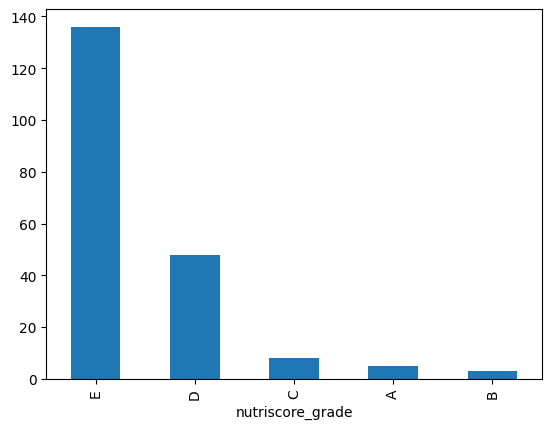

In [108]:
nutrient_master_df['nutriscore_grade'].value_counts().plot(kind='bar')

Dishes with a poor nutri score definitely dominate in this menu.

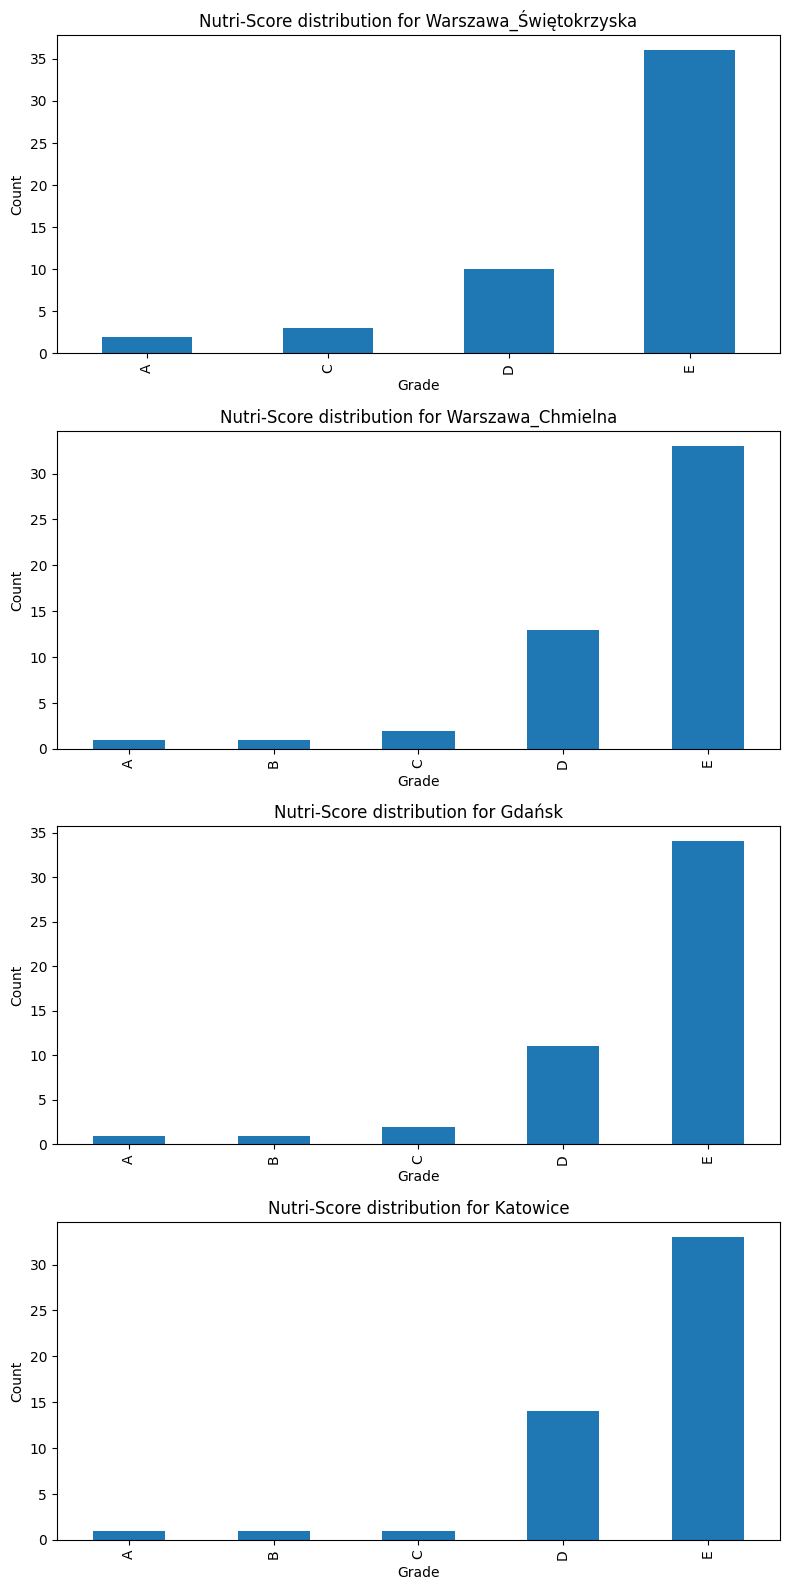

In [124]:
cities = nutrient_master_df['location'].unique()

fig, axes = plt.subplots(len(cities), 1, figsize=(8, 4 * len(cities)))
axes = np.atleast_1d(axes).flatten()

for ax, city in zip(axes, cities):

    nutrient_master_df.loc[
        nutrient_master_df['location'] == city,
        'nutriscore_grade'
    ].value_counts().sort_index().plot(
        kind='bar',
        ax=ax
    )

    ax.set_title(f'Nutri-Score distribution for {city}')
    ax.set_xlabel('Grade')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In each location, dishes with a low nutri score dominate.

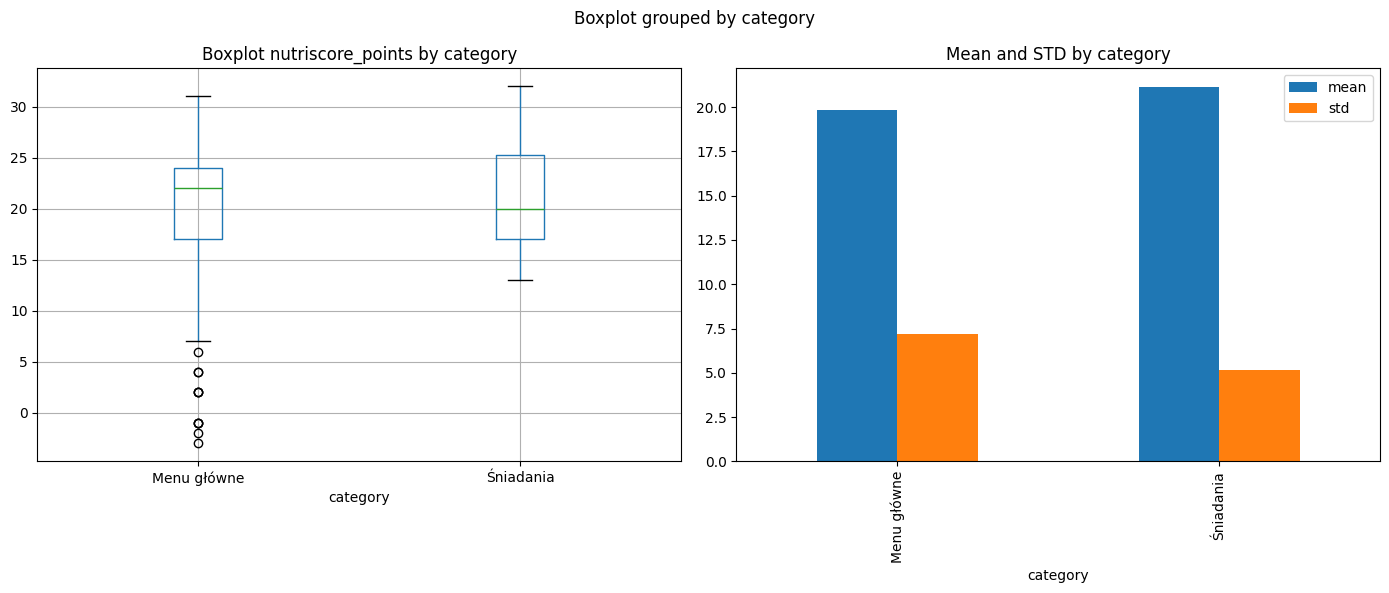

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

nutrient_master_df.boxplot(column='nutriscore_points',by='category', ax=axes[0])
axes[0].set_title("Boxplot nutriscore_points by category")

stats = nutrient_master_df.groupby('category')['nutriscore_points'].describe()[['mean', 'std']]
stats.plot(kind='bar', ax=axes[1])

axes[1].set_title("Mean and STD by category")

plt.tight_layout()
plt.show()

In [111]:
print('Top 5 healthiest dishes:')
nutrient_master_df.nsmallest(5, 'nutriscore_points')[['dish_name', 'nutriscore_grade', 'calories']]

Top 5 healthiest dishes:


,dish_name,nutriscore_grade,calories
182,CHICKEN & PESTO MAFALDINE,A,696.74
132,CHICKEN & PESTO MAFALDINE,A,711.02
2,SWEET POTATO CHIPS,A,281.72
32,CHICKEN & PESTO MAFALDINE,A,710.27
83,CHICKEN & PESTO MAFALDINE,A,725.52


In [112]:
print('Top 5 unhealthiest dishes:')
nutrient_master_df.nlargest(5, 'nutriscore_points')[['dish_name', 'nutriscore_grade', 'calories']]

Top 5 unhealthiest dishes:


,dish_name,nutriscore_grade,calories
44,BACON SANDWICH,E,994.60
94,BACON SANDWICH,E,1048.30
37,CAESAR,E,1483.53
143,BACON SANDWICH,E,1005.80
193,BACON SANDWICH,E,1008.65


In [113]:
corr = nutrient_master_df[['price','calories','protein','nutriscore_points']].corr()
print(corr)

                      price  calories   protein  nutriscore_points
price              1.000000  0.203093  0.473131           0.043294
calories           0.203093  1.000000  0.807563           0.579305
protein            0.473131  0.807563  1.000000           0.346202
nutriscore_points  0.043294  0.579305  0.346202           1.000000


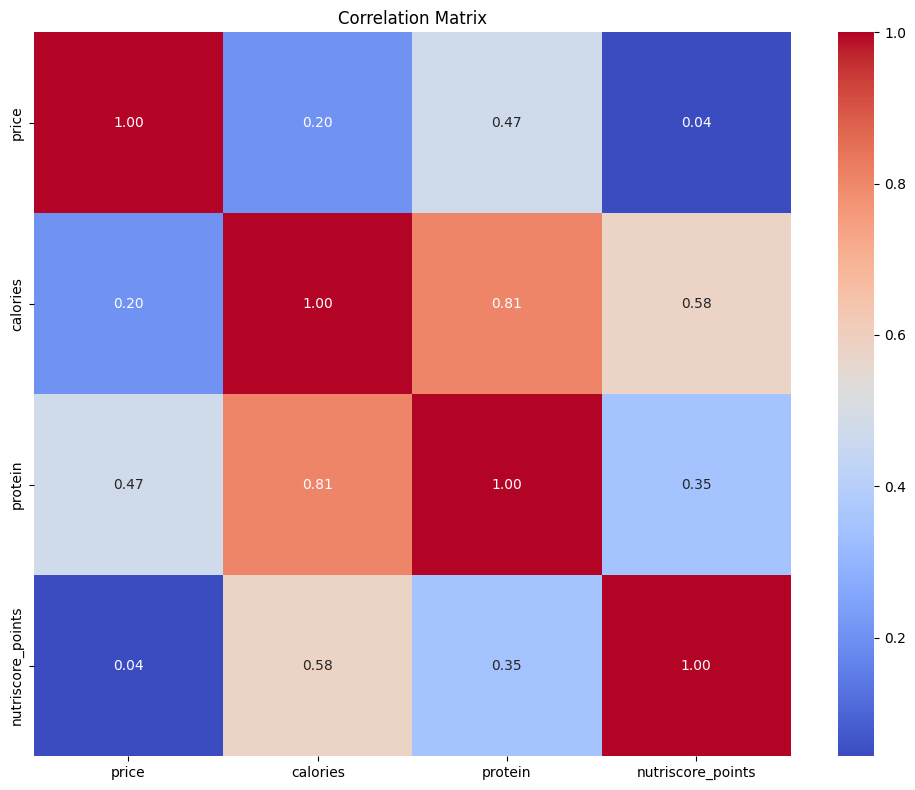

In [114]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

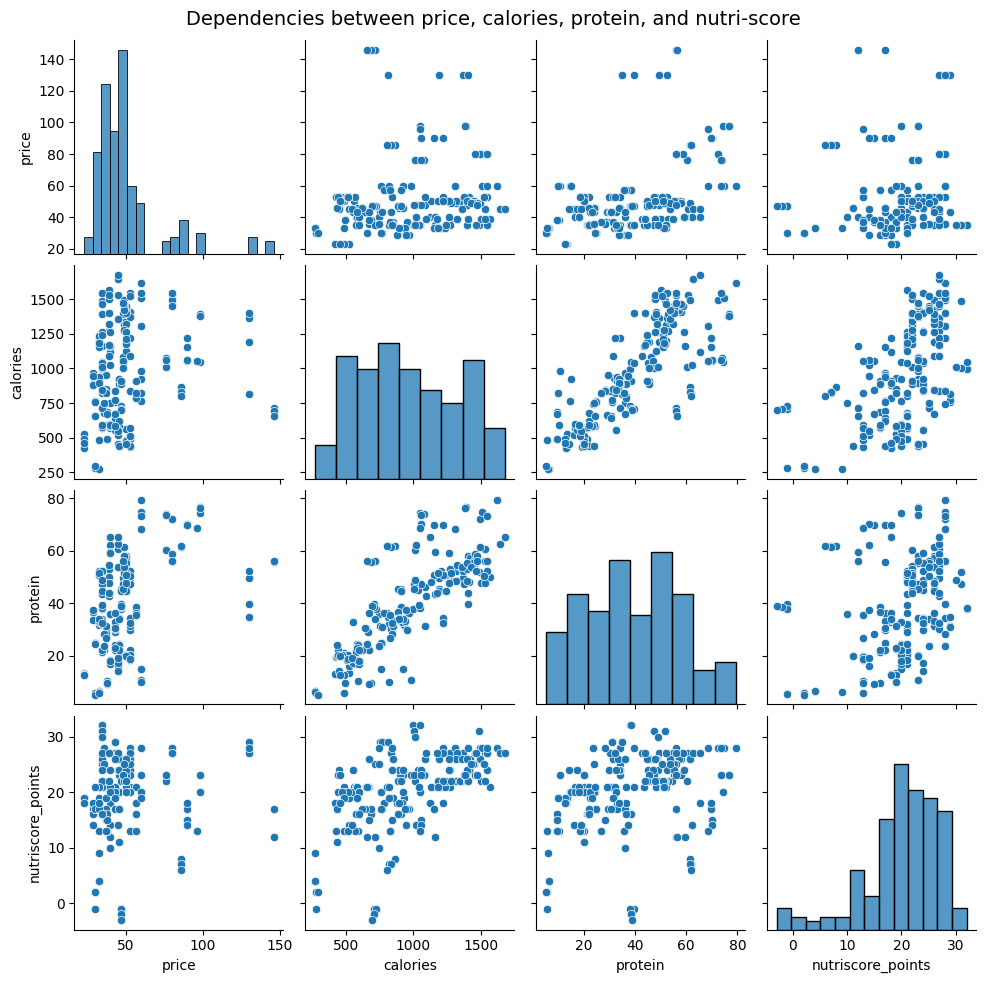

In [131]:
g = sns.pairplot(nutrient_master_df[['price', 'calories', 'protein', 'nutriscore_points']])
g.figure.subplots_adjust(top=0.95)
g.figure.suptitle('Dependencies between price, calories, protein, and nutri-score', fontsize=14)
plt.show()

In [116]:
nutrient_master_df['location'].value_counts()

location
Warszawa_Świętokrzyska    51
Warszawa_Chmielna         50
Katowice                  50
Gdańsk                    49
Name: count, dtype: int64

Dataset is balanced, there is almost the same number of dishes across locations.

In [117]:
price_comparison = nutrient_master_df.pivot_table(values='price', index='dish_name',columns='location', aggfunc='mean')
price_comparison.head()

location,Gdańsk,Katowice,Warszawa_Chmielna,Warszawa_Świętokrzyska
dish_name,,,,
ASIAN CHICKEN BOWL,NaN,NaN,NaN,39.99
AVOCADO TOAST,34.99,34.99,34.99,34.99
AïOLI BEEF TATAR 2.0,45.99,45.99,45.99,45.99
AïOLI BREAKKIE PIZZA,32.99,32.99,32.99,32.99
AïOLI BREAKKIE PIZZA VEGE,28.99,28.99,28.99,28.99


In [118]:
missing_dishes = price_comparison[price_comparison.isnull().any(axis=1)]
print(f"Number of dishes not available at all locations: {len(missing_dishes)}")
missing_dishes.head()

Number of dishes not available at all locations: 2


location,Gdańsk,Katowice,Warszawa_Chmielna,Warszawa_Świętokrzyska
dish_name,,,,
ASIAN CHICKEN BOWL,NaN,NaN,NaN,39.99
HACHE STEAK,NaN,75.99,75.99,75.99


In [119]:
inconsistent = price_comparison[price_comparison.nunique(axis=1) > 1]
print(f"Dishes with different prices across locations: {len(inconsistent)}")
inconsistent.head()

Dishes with different prices across locations: 1


location,Gdańsk,Katowice,Warszawa_Chmielna,Warszawa_Świętokrzyska
dish_name,,,,
AïOLI SEASONAL STEAK,95.99,145.99,145.99,145.99


In [125]:
print('Average dish prices per nutri-score grade:')
print(nutrient_master_df.groupby('nutriscore_grade')['price'].mean().round(2))

Average dish prices per nutri-score grade:
nutriscore_grade
A    43.59
B    29.99
C    60.36
D    51.14
E    50.46
Name: price, dtype: float64
